[plain] iter 0, avg true return = 0.6160
[plain] iter 100, avg true return = 2.4812
[plain] iter 200, avg true return = 3.0372
[plain] iter 300, avg true return = 3.1408
[plain] iter 400, avg true return = 3.2072
[plain] iter 500, avg true return = 3.1620
[plain] iter 600, avg true return = 3.1348
[plain] iter 700, avg true return = 3.2072
[plain] iter 800, avg true return = 3.1880
[plain] iter 900, avg true return = 3.2060
[plain] iter 1000, avg true return = 3.2500
[plain] iter 1100, avg true return = 3.2436
[plain] iter 1200, avg true return = 3.2092
[plain] iter 1300, avg true return = 3.2772
[plain] iter 1400, avg true return = 3.2456
[plain] iter 1500, avg true return = 3.2960
[plain] iter 1600, avg true return = 3.2752
[plain] iter 1700, avg true return = 3.2272
[plain] iter 1800, avg true return = 3.3092
[plain] iter 1900, avg true return = 3.2868
[plain] iter 2000, avg true return = 3.2808
[plain] iter 2100, avg true return = 3.2976
[plain] iter 2200, avg true return = 3.2564


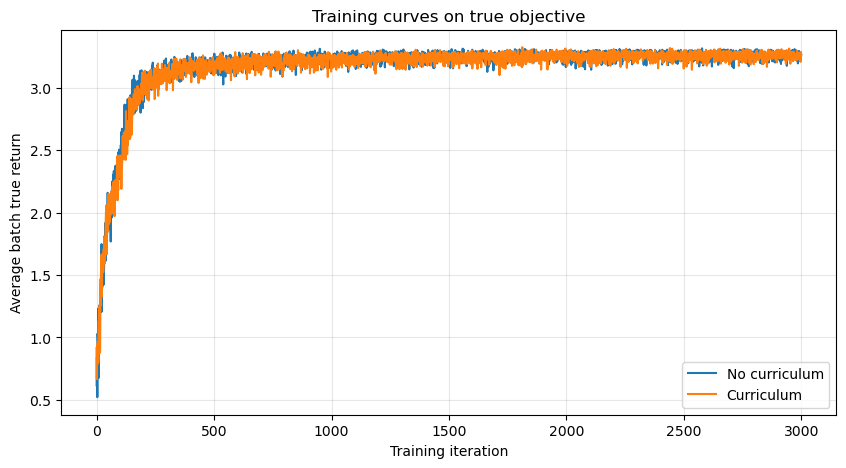

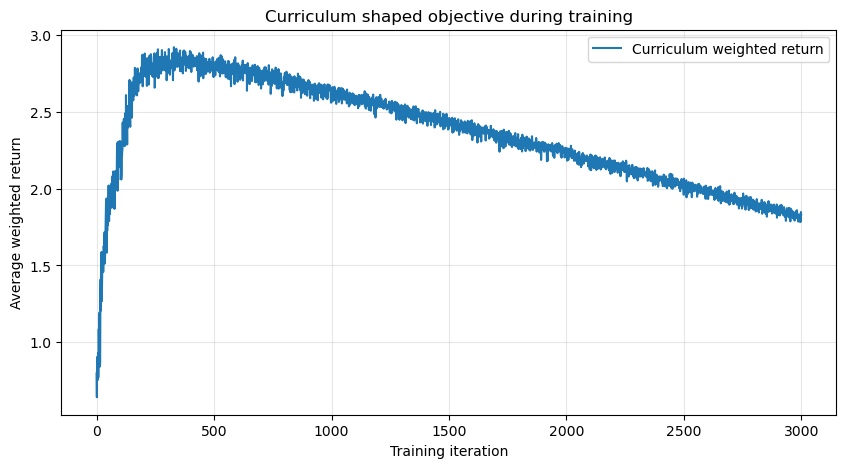

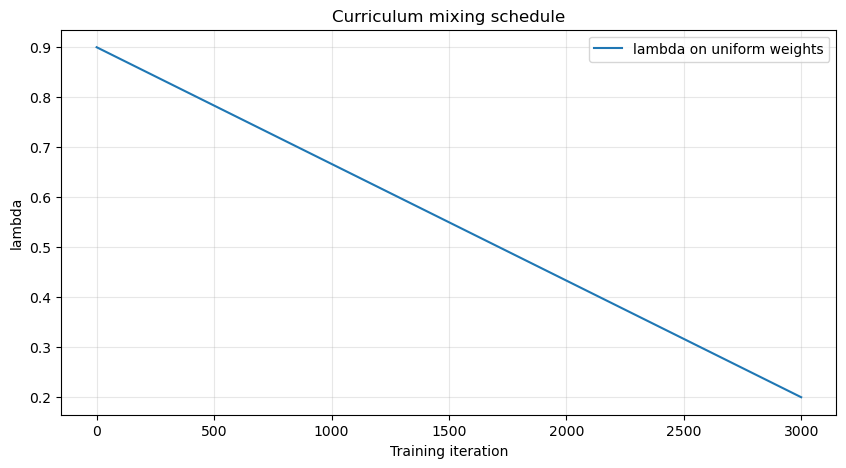

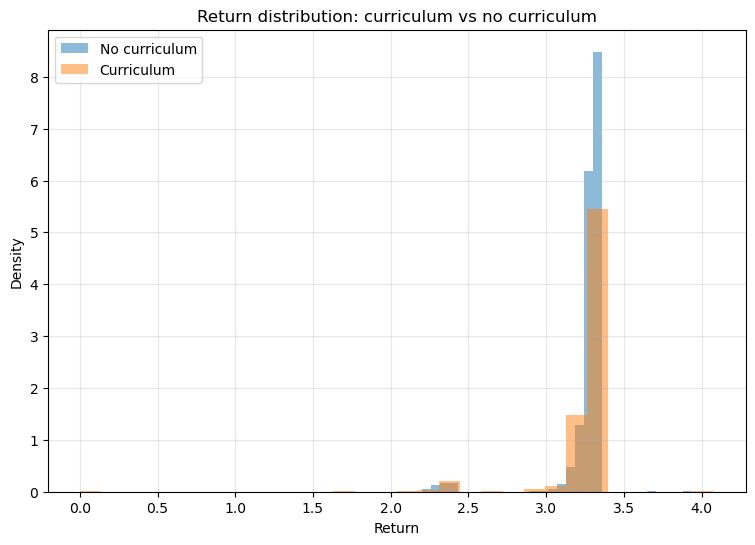

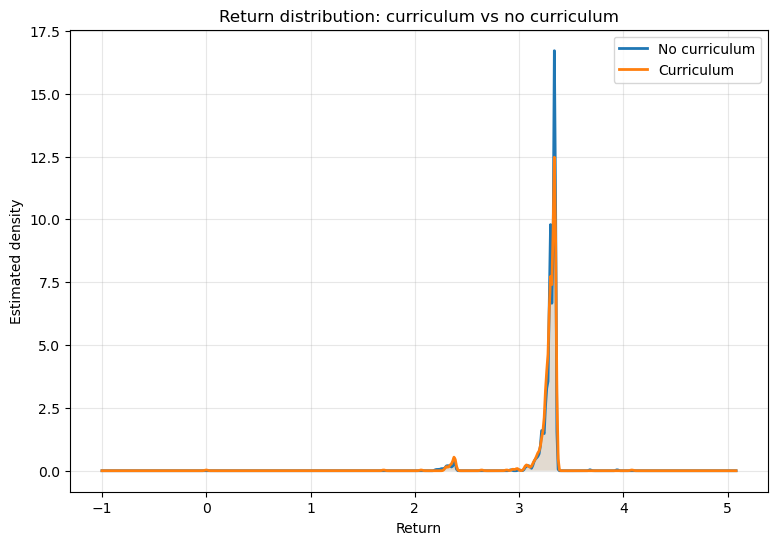

In [11]:
import numpy as np
import matplotlib.pyplot as plt


# =========================
# Environment: original 8x8 GridWorld
# =========================
class GridWorld:
    def __init__(self, d, size=8, danger=[7, 1], goal=[4, 5], wall=[2, 5],
                 coins=[(1, 6), (4, 2), (5, 5)], horizon=50):
        self.noise = None
        self.d = d
        self.size = size
        self.horizon = horizon
        self.goal = tuple(goal)
        self.danger = tuple(danger)
        self.wall = tuple(wall)
        self._init_coins = tuple(map(tuple, coins))
        self.coins = set(self._init_coins)
        self.collected_coins = set()
        self.collected = 0
        self.done = False
        self.sparse = False
        self.pos = (0, 7)
        self.t = 0
        self.time_weight = 1.0
        self.just_collected_coin = False

        self.state_weight = {}
        for i in range(self.size):
            for j in range(self.size):
                self.state_weight[(i, j)] = 1.0
        self.state_weight[self.wall] = 0.0

    def reset(self):
        self.done = False
        self.pos = (0, 7)
        self.t = 0
        self.collected = 0
        self.collected_coins = set()
        self.coins = set(self._init_coins)
        self.just_collected_coin = False
        return self.pos

    def step(self, intended_action):
        probs = np.full(4, 0.03)
        probs[intended_action] = 0.91
        action = np.random.choice(4, p=probs)

        x, y = self.pos
        if action == 0:
            x = max(0, x - 1)               # up
        if action == 1:
            x = min(self.size - 1, x + 1)   # down
        if action == 2:
            y = max(0, y - 1)               # left
        if action == 3:
            y = min(self.size - 1, y + 1)   # right

        if (x, y) != self.wall:
            self.pos = (x, y)

        self.just_collected_coin = False
        if self.pos in self.coins:
            self.just_collected_coin = True
            self.collected += 1
            self.collected_coins.add(self.pos)
            self.coins.remove(self.pos)

        self.t += 1
        self.done = (
            (self.t >= self.horizon)
            or (self.pos == self.goal)
            or (self.pos == self.danger)
        )
        return self.pos, self.done

    def base_reward(self):
        return (
            (1 - int(self.pos == self.danger))
            * (
                int(self.just_collected_coin)
                + 1.5 * int(self.pos == self.goal)
                - self.time_weight / self.horizon
            )
        )

    def immediate_reward(self):
        return self.state_weight[self.pos] * self.base_reward()


# =========================
# Policy
# =========================
def softmax(logits):
    logits = np.asarray(logits, dtype=np.float64)
    exps = np.exp(logits - np.max(logits))
    probs = exps / np.sum(exps)
    probs = probs / np.sum(probs)
    return probs


class Policy:
    def __init__(self, grid_size, action_dim, init_scale=0.1, seed=0):
        self.grid_size = grid_size
        self.state_dim = grid_size * grid_size
        self.action_dim = action_dim
        rng = np.random.default_rng(seed)
        self.theta = rng.normal(0.0, init_scale, size=(self.state_dim, self.action_dim))

    def state_index(self, state):
        return state[0] * self.grid_size + state[1]

    def act(self, state):
        s_idx = self.state_index(state)
        probs = softmax(self.theta[s_idx])
        action = np.random.choice(len(probs), p=probs)
        return action, probs

    def grad_log_prob(self, state, action):
        s_idx = self.state_index(state)
        probs = softmax(self.theta[s_idx])
        grad_row = -probs.copy()
        grad_row[action] += 1.0
        return s_idx, grad_row


# =========================
# Helpers
# =========================
def set_all_weights_to_one(env):
    for s in env.state_weight:
        env.state_weight[s] = 1.0
    env.state_weight[env.wall] = 0.0


def unit_weight_map(grid_size, wall):
    w = {(i, j): 1.0 for i in range(grid_size) for j in range(grid_size)}
    w[tuple(wall)] = 0.0
    return w


def rollout_batch(
    policy,
    grid_size=8,
    danger=[7, 1],
    goal=[4, 5],
    wall=[2, 5],
    horizon=50,
    coins=None,
    m=50,
    seed=0,
    state_weight_map=None,
):
    np.random.seed(seed)

    if coins is None:
        coins = [(1, 6), (4, 2), (5, 5)]

    d = 4 + len(coins)
    env = GridWorld(
        d,
        size=grid_size,
        danger=danger,
        goal=goal,
        wall=wall,
        coins=coins,
        horizon=horizon,
    )

    if state_weight_map is None:
        set_all_weights_to_one(env)
    else:
        env.state_weight = state_weight_map.copy()
        env.state_weight[env.wall] = 0.0

    rollouts = []
    shaped_returns = []
    true_returns = []

    for _ in range(m):
        s = env.reset()
        done = False

        traj = {
            "states": [],
            "actions": [],
            "base_rewards": [],
            "steps": 0,
            "coins": 0,
        }

        shaped_G = 0.0
        true_G = 0.0

        while not done:
            a, _ = policy.act(s)
            traj["states"].append(s)
            traj["actions"].append(a)

            s, done = env.step(a)

            r_base = env.base_reward()
            r_shaped = env.immediate_reward()

            traj["base_rewards"].append(r_base)
            shaped_G += r_shaped
            true_G += r_base

        traj["steps"] = env.t
        traj["coins"] = env.collected

        rollouts.append(traj)
        shaped_returns.append(shaped_G)
        true_returns.append(true_G)

    return rollouts, np.array(shaped_returns), np.array(true_returns)


def get_visit_probs(rollouts, grid_size):
    counts = {(i, j): 0.0 for i in range(grid_size) for j in range(grid_size)}
    total = 0.0

    for traj in rollouts:
        for s in traj["states"]:
            counts[s] += 1.0
            total += 1.0

    probs = {}
    if total == 0:
        for s in counts:
            probs[s] = 0.0
    else:
        for s in counts:
            probs[s] = counts[s] / total

    return probs


def inverse_visitation_weights_mean1(
    probs,
    wall,
    alpha=0.5,
    eps=1e-6,
    w_min=0.5,
    w_max=3.0,
):
    """
    Build weights proportional to 1 / (p(s)+eps)^alpha
    and normalize so the mean over valid states is 1.
    """
    wall = tuple(wall)
    valid_states = [s for s in probs if s != wall]

    raw = {}
    for s in valid_states:
        raw[s] = 1.0 / ((probs[s] + eps) ** alpha)

    mean_raw = np.mean(list(raw.values())) if len(raw) > 0 else 1.0
    weights = {}

    for s in probs:
        if s == wall:
            weights[s] = 0.0
        else:
            weights[s] = raw[s] / mean_raw

    for s in valid_states:
        weights[s] = min(w_max, max(w_min, weights[s]))

    # renormalize after clipping to keep mean exactly 1
    clipped_mean = np.mean([weights[s] for s in valid_states]) if len(valid_states) > 0 else 1.0
    for s in valid_states:
        weights[s] /= clipped_mean

    weights[wall] = 0.0
    return weights


def mix_with_uniform(weight_map, grid_size, wall, lam=0.7):
    """
    lam = weight on uniform map
    1-lam = weight on inverse-visitation map
    """
    wall = tuple(wall)
    mixed = {}
    for i in range(grid_size):
        for j in range(grid_size):
            s = (i, j)
            if s == wall:
                mixed[s] = 0.0
            else:
                mixed[s] = lam * 1.0 + (1.0 - lam) * weight_map[s]
    mixed[wall] = 0.0
    return mixed


def compute_gradient_from_weight_map(policy, rollouts, weight_map):
    grad_theta = np.zeros_like(policy.theta)

    weighted_returns = []
    for traj in rollouts:
        G = 0.0
        for s, r_base in zip(traj["states"], traj["base_rewards"]):
            G += weight_map[s] * r_base
        weighted_returns.append(G)

    weighted_returns = np.array(weighted_returns)
    baseline = float(np.mean(weighted_returns))

    for traj, G in zip(rollouts, weighted_returns):
        adv = G - baseline
        for state, action in zip(traj["states"], traj["actions"]):
            s_idx, grad_row = policy.grad_log_prob(state, action)
            grad_theta[s_idx] += adv * grad_row

    grad_theta /= len(rollouts)
    return grad_theta, weighted_returns


# =========================
# Training: no curriculum baseline
# =========================
def train_plain_true_objective(
    m=50,
    eta=0.2,
    grid_size=8,
    danger=[7, 1],
    goal=[4, 5],
    wall=[2, 5],
    horizon=50,
    coins=None,
    seed=0,
    n_iters=3000,
):
    if coins is None:
        coins = [(1, 6), (4, 2), (5, 5)]

    policy = Policy(
        grid_size=grid_size,
        action_dim=4,
        init_scale=0.1,
        seed=seed,
    )

    avg_true_returns = []
    avg_train_returns = []

    w_unit = unit_weight_map(grid_size, wall)

    for g in range(n_iters):
        rollouts, _, true_returns = rollout_batch(
            policy,
            grid_size=grid_size,
            danger=danger,
            goal=goal,
            wall=wall,
            horizon=horizon,
            coins=coins,
            m=m,
            seed=seed + 10000 * g + 111,
            state_weight_map=None,
        )

        grad, train_returns = compute_gradient_from_weight_map(policy, rollouts, w_unit)
        policy.theta = policy.theta + eta * grad

        avg_true_returns.append(float(np.mean(true_returns)))
        avg_train_returns.append(float(np.mean(train_returns)))

        if g % 100 == 0:
            print(f"[plain] iter {g}, avg true return = {np.mean(true_returns):.4f}")

    history = {
        "avg_true_returns": np.array(avg_true_returns),
        "avg_train_returns": np.array(avg_train_returns),
    }
    return policy, history


# =========================
# Training: simple inverse-visitation curriculum
# =========================
def train_inverse_visitation_curriculum(
    m=50,
    eta=0.2,
    grid_size=8,
    danger=[7, 1],
    goal=[4, 5],
    wall=[2, 5],
    horizon=50,
    coins=None,
    seed=0,
    n_iters=3000,
    alpha=0.5,
    eps=1e-6,
    w_min=0.5,
    w_max=3.0,
    lam_start=0.9,
    lam_end=0.2,
):
    """
    Simple curriculum:
      1. Estimate visitation probabilities from current rollouts
      2. Build inverse-visitation weights with mean 1
      3. Mix with uniform weights: lam*1 + (1-lam)*w_inv
      4. Train on that shaped objective
      5. Evaluate separately on true objective
    """

    if coins is None:
        coins = [(1, 6), (4, 2), (5, 5)]

    policy = Policy(
        grid_size=grid_size,
        action_dim=4,
        init_scale=0.1,
        seed=seed,
    )

    avg_true_returns = []
    avg_weighted_returns = []
    lam_history = []

    for g in range(n_iters):
        lam = lam_start + (lam_end - lam_start) * (g / max(1, n_iters - 1))
        lam_history.append(lam)

        rollouts, _, true_returns = rollout_batch(
            policy,
            grid_size=grid_size,
            danger=danger,
            goal=goal,
            wall=wall,
            horizon=horizon,
            coins=coins,
            m=m,
            seed=seed + 10000 * g + 1,
            state_weight_map=None,
        )

        probs = get_visit_probs(rollouts, grid_size)

        w_inv = inverse_visitation_weights_mean1(
            probs=probs,
            wall=wall,
            alpha=alpha,
            eps=eps,
            w_min=w_min,
            w_max=w_max,
        )

        w_mix = mix_with_uniform(
            weight_map=w_inv,
            grid_size=grid_size,
            wall=wall,
            lam=lam,
        )

        grad, weighted_returns = compute_gradient_from_weight_map(policy, rollouts, w_mix)
        policy.theta = policy.theta + eta * grad

        avg_true_returns.append(float(np.mean(true_returns)))
        avg_weighted_returns.append(float(np.mean(weighted_returns)))

        if g % 100 == 0:
            print(
                f"[curr]  iter {g}, avg true return = {np.mean(true_returns):.4f}, "
                f"avg weighted return = {np.mean(weighted_returns):.4f}, "
                f"lam={lam:.3f}, w(start)={w_mix[(0,7)]:.3f}, w(goal)={w_mix[tuple(goal)]:.3f}"
            )

    history = {
        "avg_true_returns": np.array(avg_true_returns),
        "avg_weighted_returns": np.array(avg_weighted_returns),
        "lam_history": np.array(lam_history),
    }
    return policy, history


# =========================
# Evaluation
# =========================
def collect_returns(
    policy,
    grid_size=8,
    danger=[7, 1],
    goal=[4, 5],
    wall=[2, 5],
    horizon=50,
    coins=None,
    n_episodes=1000,
    seed=123,
):
    np.random.seed(seed)

    if coins is None:
        coins = [(1, 6), (4, 2), (5, 5)]

    d = 4 + len(coins)
    env = GridWorld(
        d,
        size=grid_size,
        danger=danger,
        goal=goal,
        wall=wall,
        coins=coins,
        horizon=horizon,
    )

    set_all_weights_to_one(env)

    returns = []
    goal_count = 0
    danger_count = 0
    steps_list = []
    coins_list = []

    for _ in range(n_episodes):
        s = env.reset()
        done = False
        G = 0.0

        while not done:
            a, _ = policy.act(s)
            s, done = env.step(a)
            G += env.base_reward()

        returns.append(G)
        steps_list.append(env.t)
        coins_list.append(env.collected)

        if env.pos == tuple(goal):
            goal_count += 1
        if env.pos == tuple(danger):
            danger_count += 1

    stats = {
        "returns": np.array(returns),
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
        "goal_rate": goal_count / n_episodes,
        "danger_rate": danger_count / n_episodes,
        "mean_steps": float(np.mean(steps_list)),
        "mean_coins": float(np.mean(coins_list)),
    }
    return stats


# =========================
# Plotting
# =========================
def gaussian_kde_manual(samples, x_grid, bandwidth=None):
    samples = np.asarray(samples, dtype=np.float64)
    n = len(samples)

    if bandwidth is None:
        std = np.std(samples, ddof=1)
        iqr = np.percentile(samples, 75) - np.percentile(samples, 25)
        sigma = min(std, iqr / 1.34) if iqr > 0 else std
        if sigma < 1e-8:
            sigma = max(std, 1.0)
        bandwidth = 0.9 * sigma * n ** (-1 / 5)
        bandwidth = max(bandwidth, 1e-3)

    u = (x_grid[:, None] - samples[None, :]) / bandwidth
    kernel_vals = np.exp(-0.5 * u ** 2) / np.sqrt(2 * np.pi)
    density = np.mean(kernel_vals, axis=1) / bandwidth
    return density


def plot_return_distributions(curr_returns, plain_returns, bins=30):
    plt.figure(figsize=(9, 6))
    plt.hist(plain_returns, bins=bins, alpha=0.5, density=True, label="No curriculum")
    plt.hist(curr_returns, bins=bins, alpha=0.5, density=True, label="Curriculum")
    plt.xlabel("Return")
    plt.ylabel("Density")
    plt.title("Return distribution: curriculum vs no curriculum")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_return_kdes(curr_returns, plain_returns):
    all_returns = np.concatenate([curr_returns, plain_returns])
    x_grid = np.linspace(np.min(all_returns) - 1, np.max(all_returns) + 1, 500)

    curr_density = gaussian_kde_manual(curr_returns, x_grid)
    plain_density = gaussian_kde_manual(plain_returns, x_grid)

    plt.figure(figsize=(9, 6))
    plt.plot(x_grid, plain_density, linewidth=2, label="No curriculum")
    plt.plot(x_grid, curr_density, linewidth=2, label="Curriculum")
    plt.fill_between(x_grid, plain_density, alpha=0.15)
    plt.fill_between(x_grid, curr_density, alpha=0.15)
    plt.xlabel("Return")
    plt.ylabel("Estimated density")
    plt.title("Return distribution: curriculum vs no curriculum")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# =========================
# Example run
# =========================
if __name__ == "__main__":
    grid_size = 8
    danger = [7, 1]
    goal = [4, 5]
    wall = [2, 5]
    horizon = 50
    coins = [(1, 6), (4, 2), (5, 5)]
    seed = 12
    n_iters = 3000
    m = 50

    # Baseline: no curriculum
    policy_plain, hist_plain = train_plain_true_objective(
        m=m,
        eta=0.2,
        grid_size=grid_size,
        danger=danger,
        goal=goal,
        wall=wall,
        horizon=horizon,
        coins=coins,
        seed=seed,
        n_iters=n_iters,
    )

    # Curriculum: simple inverse-visitation shaping
    policy_curr, hist_curr = train_inverse_visitation_curriculum(
        m=m,
        eta=0.2,
        grid_size=grid_size,
        danger=danger,
        goal=goal,
        wall=wall,
        horizon=horizon,
        coins=coins,
        seed=seed,
        n_iters=n_iters,
        alpha=0.5,     # strength of inverse-visitation weighting
        eps=1e-4,
        w_min=0.5,
        w_max=3.0,
        lam_start=0.9, # start mostly uniform
        lam_end=0.2,   # later allow stronger shaping
    )

    # Evaluate both on true objective
    eval_plain = collect_returns(
        policy_plain,
        grid_size=grid_size,
        danger=danger,
        goal=goal,
        wall=wall,
        horizon=horizon,
        coins=coins,
        n_episodes=1000,
        seed=123,
    )

    eval_curr = collect_returns(
        policy_curr,
        grid_size=grid_size,
        danger=danger,
        goal=goal,
        wall=wall,
        horizon=horizon,
        coins=coins,
        n_episodes=1000,
        seed=456,
    )

    print("\n=== Final Evaluation on True Objective ===")
    print(
        f"No curriculum | mean={eval_plain['mean_return']:.4f}, "
        f"std={eval_plain['std_return']:.4f}, "
        f"goal_rate={eval_plain['goal_rate']:.4f}, "
        f"danger_rate={eval_plain['danger_rate']:.4f}, "
        f"mean_steps={eval_plain['mean_steps']:.4f}, "
        f"mean_coins={eval_plain['mean_coins']:.4f}"
    )
    print(
        f"Curriculum    | mean={eval_curr['mean_return']:.4f}, "
        f"std={eval_curr['std_return']:.4f}, "
        f"goal_rate={eval_curr['goal_rate']:.4f}, "
        f"danger_rate={eval_curr['danger_rate']:.4f}, "
        f"mean_steps={eval_curr['mean_steps']:.4f}, "
        f"mean_coins={eval_curr['mean_coins']:.4f}"
    )

    # Training curves on true objective
    plt.figure(figsize=(10, 5))
    plt.plot(hist_plain["avg_true_returns"], label="No curriculum")
    plt.plot(hist_curr["avg_true_returns"], label="Curriculum")
    plt.xlabel("Training iteration")
    plt.ylabel("Average batch true return")
    plt.title("Training curves on true objective")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Curriculum weighted objective
    plt.figure(figsize=(10, 5))
    plt.plot(hist_curr["avg_weighted_returns"], label="Curriculum weighted return")
    plt.xlabel("Training iteration")
    plt.ylabel("Average weighted return")
    plt.title("Curriculum shaped objective during training")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Mixing schedule
    plt.figure(figsize=(10, 5))
    plt.plot(hist_curr["lam_history"], label="lambda on uniform weights")
    plt.xlabel("Training iteration")
    plt.ylabel("lambda")
    plt.title("Curriculum mixing schedule")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Return distributions
    plot_return_distributions(eval_curr["returns"], eval_plain["returns"], bins=30)
    plot_return_kdes(eval_curr["returns"], eval_plain["returns"])

iter 0, avg shaped return = 149.0000, w(start)=0.500, w(goal)=1.080
iter 100, avg shaped return = 80.4124, w(start)=0.517, w(goal)=1.286
iter 200, avg shaped return = 91.0500, w(start)=0.533, w(goal)=1.478
iter 300, avg shaped return = 98.8201, w(start)=0.550, w(goal)=1.567
iter 400, avg shaped return = 108.4153, w(start)=0.567, w(goal)=1.624
iter 500, avg shaped return = 119.5375, w(start)=0.583, w(goal)=1.636
iter 600, avg shaped return = 114.4330, w(start)=0.600, w(goal)=1.734
iter 700, avg shaped return = 123.7316, w(start)=0.617, w(goal)=1.718
iter 800, avg shaped return = 123.3009, w(start)=0.633, w(goal)=1.665
iter 900, avg shaped return = 128.4923, w(start)=0.650, w(goal)=1.686
iter 1000, avg shaped return = 132.8840, w(start)=0.667, w(goal)=1.644
iter 1100, avg shaped return = 131.4883, w(start)=0.683, w(goal)=1.644
iter 1200, avg shaped return = 136.3874, w(start)=0.700, w(goal)=1.613
iter 1300, avg shaped return = 133.9731, w(start)=0.717, w(goal)=1.569
iter 1400, avg shaped

KeyboardInterrupt: 